# DNN Intro, Approximation Theory, and Covariate-Driven Training
**Course:** MAT 485/685  
**Topic:** Deep Neural Networks, ReLU approximation, and training with weather / social determinants of health covariates

We will cover:
1. the ReLU activation function,
2. one-dimensional function approximation by neural networks,
3. a precise statement of the Universal Approximation Theorem,
4. parameter interpretation,
5. connecting epidemiological data with deep neural networks.


## 1. Neural networks as parameterized function approximators

A neural network is a function.  
In the simplest one-dimensional setting, the input is a scalar $x \in \mathbb{R}$ and the output is a scalar $f_\theta(x) \in \mathbb{R}$, where $\theta$ denotes all trainable parameters.

A commonly used activation function is the **rectified linear unit**:
$$
\operatorname{ReLU}(z) := \max(0,z)
=
\begin{cases}
z, & z \ge 0,\\
0, & z < 0.
\end{cases}
$$

A single ReLU neuron with scalar input has the form
$$
x \mapsto \operatorname{ReLU}(w x + b),
$$
where:
- $w \in \mathbb{R}$ is the input weight,
- $b \in \mathbb{R}$ is the bias.

A one-hidden-layer neural network with $m$ hidden units is
$$
f_\theta(x) = c + \sum_{j=1}^m a_j \operatorname{ReLU}(w_j x + b_j),
$$
where:
- $a_j \in \mathbb{R}$ are output weights,
- $w_j, b_j \in \mathbb{R}$ are hidden-layer parameters,
- $c \in \mathbb{R}$ is an output bias.

## 2. Geometry of one ReLU unit

Consider
$$
\phi(x) = \operatorname{ReLU}(w x + b).
$$

The point at which the behavior changes is determined by
$$
w x + b = 0.
$$
If $w \ne 0$, then the breakpoint is
$$
x = -\frac{b}{w}.
$$

Example. A neural network with 1 hidden layer which contains 4 nodes. Write the function explicitely. Plot.

Thus:
- $b$ helps determine where the breakpoint occurs,
- $w$ controls the horizontal scaling and orientation,
- the outer coefficient $a$ controls how strongly that neuron contributes to the final output.

In this sense, the parameters do not merely rescale the function: they determine where and how the graph bends.

## 3. One-dimensional piecewise linear approximation

A key fact is that linear combinations of shifted ReLU functions generate piecewise linear functions.

A convenient representation is
$$
f(x) = c + \sum_{j=1}^m w_j \operatorname{ReLU}(x - b_j/w_j),
$$
where the numbers $t_1,\dots,t_m$ are breakpoints.

### Slope interpretation
For $x < b_j/w_j$, the term $\operatorname{ReLU}(x-b_j/w_j)$ contributes nothing.  
For $x >= b_j/w_j$, it contributes the linear term $w_jx-b_j$.

Therefore, every time we pass a breakpoint $b_j/w_j$, the slope of the total function changes by $a_j$.

This yields the interpretation:

> **Each hidden ReLU unit contributes one breakpoint, and the network builds a function by combining many breakpoints.**

## 4. Worked example

Consider
$$
f(x) = 0.2\,\operatorname{ReLU}(x)
-0.5\,\operatorname{ReLU}(x+1)
+0.3\,\operatorname{ReLU}(x+2)
+0.2\,\operatorname{ReLU}(x+3).
$$

The breakpoints occur at
\[
x=0,\quad x=-1,\quad x=-2,\quad x=-3.
\]

To understand the graph, evaluate piece by piece.

### Region 1: $x < -3$
All ReLU terms are zero, so
\[
f(x)=0.
\]

### Region 2: $-3 \le x < -2$
Only $\operatorname{ReLU}(x+3)$ is active, so
\[
f(x)=0.2(x+3).
\]

### Region 3: $-2 \le x < -1$
Now $\operatorname{ReLU}(x+2)$ and $\operatorname{ReLU}(x+3)$ are active:
\[
f(x)=0.3(x+2)+0.2(x+3)=0.5x+1.2.
\]

### Region 4: $-1 \le x < 0$
Now three units are active:
\[
f(x)=-0.5(x+1)+0.3(x+2)+0.2(x+3)=0.7.
\]

### Region 5: $x \ge 0$
All four units are active:
\[
f(x)=0.2x-0.5(x+1)+0.3(x+2)+0.2(x+3)=0.2x+0.7.
\]

Hence
\[
f(x)=
\begin{cases}
0, & x<-3,\\[4pt]
0.2(x+3), & -3\le x<-2,\\[4pt]
0.5x+1.2, & -2\le x<-1,\\[4pt]
0.7, & -1\le x<0,\\[4pt]
0.2x+0.7, & x\ge 0.
\end{cases}
\]

This is a continuous piecewise linear function built from four hinges.

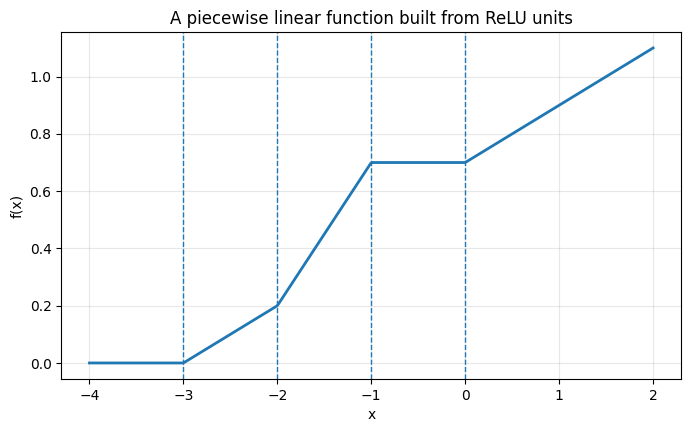

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0.0, x)

def f(x):
    return (
        0.2 * relu(x)
        - 0.5 * relu(x + 1)
        + 0.3 * relu(x + 2)
        + 0.2 * relu(x + 3)
    )

x = np.linspace(-4, 2, 500)
y = f(x)

plt.figure(figsize=(8,4.5))
plt.plot(x, y, linewidth=2)
for t in [-3, -2, -1, 0]:
    plt.axvline(t, linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("A piecewise linear function built from ReLU units")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Deep neural networks

A **deep neural network (DNN)** has more than one hidden layer.  
For example, with input $x \in \mathbb{R}^d$:

$$
h^{(1)}(x) = \sigma(W^{(1)}x + b^{(1)}),
$$
$$
h^{(2)}(x) = \sigma(W^{(2)}h^{(1)}(x) + b^{(2)}),
$$
and so on, where $\sigma$ is an activation function such as ReLU applied componentwise.

The output layer may be written
$$
f_\theta(x) = W^{(L)} h^{(L-1)}(x) + b^{(L)}.
$$

In these notes, when we write $\sigma$, we mean the activation function under discussion.  
If we specifically choose ReLU, then $\sigma(z)=\max(0,z)$ componentwise.

## 6. Universal Approximation Theorem (informal and formal statements)


In one dimension, the intuition is that we approximate a curve by many short linear pieces, and ReLU networks naturally build continuous piecewise linear functions.

### UAT in 1D
Let $g:[a,b]\to\mathbb{R}$ be a continuous function. Then for every $\varepsilon>0$, there exists a neural network $f_\theta$ such that
$$
\sup_{x\in[a,b]} |f_\theta(x)-g(x)| < \varepsilon.
$$

### UAT in Higher-dimension
Let $K \subset \mathbb{R}^d$ be compact and let $g:K\to\mathbb{R}$ be continuous. Then for every $\varepsilon>0$, there exists a neural network $f_\theta$ such that
$$
\sup_{x\in K} |f_\theta(x)-g(x)| < \varepsilon.
$$

So a neural network can approximate a target function by combining many simple nonlinear building blocks.



## 7. Why this matters for data modeling

Suppose we observe covariates $x$ and wish to predict an output $y$.  
A neural network provides a map
$$
x \mapsto f_\theta(x),
$$
where the parameters $\theta$ which contains the weights and biases are learned from data.

Thus, a DNN is not only a theoretical approximation device; it is a practical model for learning nonlinear relationships from data.

## 9 Backpropagation in a Hybrid DNN + Epidemiological Model

In this example, we use a neural network to map covariates to a transmission rate:
$$
\beta_t = g_\theta(x_t),
$$
where:
- $x_t$ = covariates at time $t$ (weather, SDOH, lagged observations, etc.),
- $g_\theta$ = neural network with parameters $\theta$,
- $\beta_t$ = transmission rate used inside the epidemiological model.

We then evolve the SIR model forward:
$$
(S_t, I_t, R_t) \mapsto (S_{t+1}, I_{t+1}, R_{t+1}),
$$
using $\beta_t$, and compare predicted infections to observed data.

The learning problem is:
$$
\min_\theta \mathcal L(\theta),
$$
where the loss measures discrepancy between model predictions and observed data.

## Computational graph

$$
x_t \rightarrow g_\theta(x_t)=\beta_t \rightarrow \text{SIR dynamics} \rightarrow \hat y_t \rightarrow \mathcal L
$$

Backpropagation applies the chain rule through this whole pipeline:
$$
\frac{\partial \mathcal L}{\partial \theta}
=
\frac{\partial \mathcal L}{\partial \hat y}
\frac{\partial \hat y}{\partial \beta}
\frac{\partial \beta}{\partial \theta}.
$$

So training updates the neural network parameters in a way that improves the final epidemiological fit.

### Step 1: A small neural network for $\beta_t$

The DNN takes a feature vector $x_t$ and returns a scalar transmission rate $\beta_t$.

To keep the interpretation simple, we use:
- one hidden layer,
- ReLU activation,
- softplus output so that $\beta_t > 0$.

In [9]:
import jax
import jax.numpy as jnp
from jax import grad, jit, value_and_grad

def init_mlp_params(key, input_dim, hidden_dim, output_dim=1, scale=0.1):
    k1, k2 = jax.random.split(key)
    params = {
        "W1": scale * jax.random.normal(k1, (hidden_dim, input_dim)),
        "b1": jnp.zeros((hidden_dim,)),
        "W2": scale * jax.random.normal(k2, (output_dim, hidden_dim)),
        "b2": jnp.zeros((output_dim,))
    }
    return params

def relu(x):
    return jnp.maximum(0.0, x)

def softplus(x):
    return jnp.log1p(jnp.exp(x))

def beta_network(params, x):
    """
    x: shape (..., input_dim)
    returns beta: shape (...,)
    """
    h = relu(x @ params["W1"].T + params["b1"])
    out = h @ params["W2"].T + params["b2"]
    beta = softplus(out[..., 0]) + 1e-6
    return beta

### Step 2: SIR dynamics driven by the DNN output

At each time $t$, the DNN produces $\beta_t = g_\theta(x_t)$.
We then use this $\beta_t$ in the SIR update equations.

For simplicity, we use Euler discretization with time step $dt$.

In [10]:
def sir_step(state, beta_t, gamma, N, dt=1.0):
    S, I, R = state
    new_infections = beta_t * S * I / N
    recoveries = gamma * I

    S_next = S - dt * new_infections
    I_next = I + dt * (new_infections - recoveries)
    R_next = R + dt * recoveries

    return jnp.array([S_next, I_next, R_next])

def simulate_sir_with_dnn(params, X, S0, I0, R0, gamma, dt=1.0):
    """
    X: shape (T, input_dim), covariates for times 0,...,T-1
    Returns:
        states: shape (T+1, 3)
        betas:  shape (T,)
    """
    N = S0 + I0 + R0
    init_state = jnp.array([S0, I0, R0])

    def body_fn(state, x_t):
        beta_t = beta_network(params, x_t)
        next_state = sir_step(state, beta_t, gamma=gamma, N=N, dt=dt)
        return next_state, (next_state, beta_t)

    final_state, (states_seq, betas) = jax.lax.scan(body_fn, init_state, X)
    states = jnp.vstack([init_state[None, :], states_seq])
    return states, betas

### Step 3: Prediction target and loss

Suppose our observed data are infected counts $y_t$.
The model predicts infected counts through the SIR trajectory:
$$
\hat y_t = I_t.
$$

We fit the neural network parameters by minimizing mean squared error:
$$
\mathcal L(\theta) = \frac{1}{T}\sum_{t=1}^T (\hat y_t - y_t)^2.
$$

This loss depends on $\theta$ indirectly through:
- the DNN output $\beta_t$,
- the SIR recursion,
- the predicted infected counts.

In [11]:
def loss_fn(params, X, y_obs, S0, I0, R0, gamma, dt=1.0):
    states, betas = simulate_sir_with_dnn(params, X, S0, I0, R0, gamma, dt)
    I_pred = states[1:, 1]   # predicted I_t for t=1,...,T
    loss = jnp.mean((I_pred - y_obs)**2) / jnp.mean(y_obs**2)
    #smooth_penalty =   jnp.mean((betas[1:] - betas[:-1]) ** 2)
    return loss #+smooth_penalty

### Step 4: Backpropagation

The key point is that JAX differentiates the full loss with respect to the DNN parameters.

Even though the loss is computed after passing through:
1. the neural network,
2. the SIR dynamics,
3. the prediction map,

JAX still computes:
\[
\nabla_\theta \mathcal L(\theta).
\]

This is backpropagation through the hybrid model.

In [12]:
#grad_loss_fn = jit(grad(loss_fn))
value_and_grad_fn = jit(value_and_grad(loss_fn))

### Step 5: A tiny synthetic example

Instead of generating y_obs from a hand-written function, we now generate it from the same NN-driven SIR model.

First:
- create covariates X_true,
- choose a "true" neural network,
- simulate the SIR trajectory using that true network,
- define y_obs from the infected trajectory.

Then:
- perturb the covariates,
- pretend we do not know the true NN,
- learn a

Initial loss: 0.008690438233315945
Gradient keys: dict_keys(['W1', 'W2', 'b1', 'b2'])
Shape of dL/dW1: (8, 4)
Shape of dL/db1: (8,)
Shape of dL/dW2: (1, 8)
Shape of dL/db2: (1,)


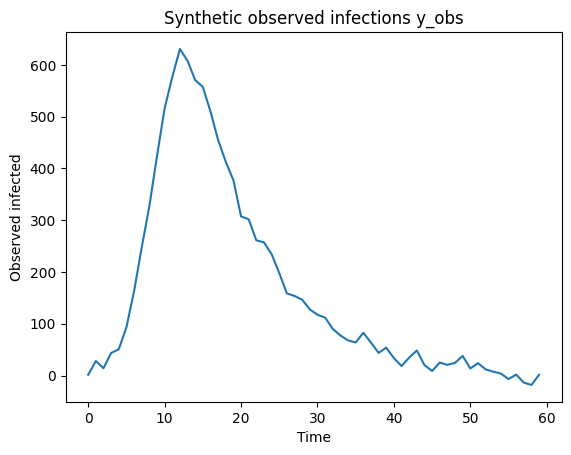

In [13]:
key = jax.random.PRNGKey(0)
key, key_true, key_init, key_noise, key_obs = jax.random.split(key, 5)

T = 60
input_dim = 4   # 4 covariates
hidden_dim = 8

t = jnp.arange(T)

# Structured covariates so that beta_t has a learnable pattern
X = jnp.column_stack([
    jnp.sin(2.0 * jnp.pi * t / T),
    jnp.cos(2.0 * jnp.pi * t / T),
    t / T,
    (t / T) ** 2
])

S0, I0, R0 = 990.0, 10.0, 0.0
gamma = 0.1

# True NN
true_params = init_mlp_params(key_true, input_dim=input_dim, hidden_dim=hidden_dim, scale=0.8)

# Generate synthetic observations from the true NN + SIR model
states_true, betas_true = simulate_sir_with_dnn(
    true_params, X, S0, I0, R0, gamma
)
y_obs = states_true[1:, 1]

# add observation noise
obs_noise_scale = 0.02 * jnp.max(y_obs)
y_obs = y_obs + obs_noise_scale * jax.random.normal(key_obs, y_obs.shape)

# Perturb the covariates
covariate_noise_scale = 0.08
X_perturbed = X + covariate_noise_scale * jax.random.normal(key_noise, X.shape)

# Initialize a new NN
params = init_mlp_params(key_init, input_dim=input_dim, hidden_dim=hidden_dim, scale=0.1)

loss_val, grads = value_and_grad_fn(params, X_perturbed, y_obs, S0, I0, R0, gamma)

print("Initial loss:", float(loss_val))
print("Gradient keys:", grads.keys())
print("Shape of dL/dW1:", grads["W1"].shape)
print("Shape of dL/db1:", grads["b1"].shape)
print("Shape of dL/dW2:", grads["W2"].shape)
print("Shape of dL/db2:", grads["b2"].shape)

plt.figure()
plt.plot(y_obs)
plt.xlabel("Time")
plt.ylabel("Observed infected")
plt.title("Synthetic observed infections y_obs")
plt.show()


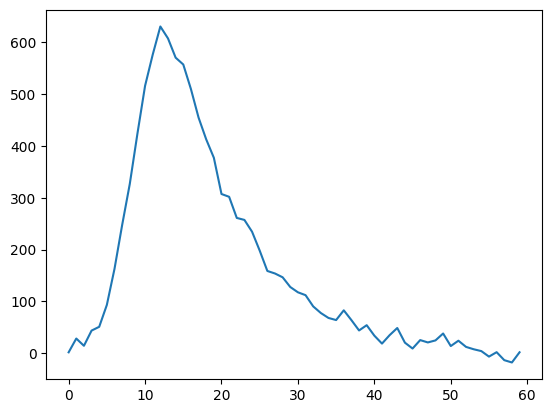

In [14]:
import matplotlib.pyplot as plt
plt.plot(y_obs)

### Step 6: One gradient descent update

A single gradient step updates the network parameters:
$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal L(\theta).
$$

This is how learning happens.

In [15]:
@jit
def gradient_step(params, X, y_obs, S0, I0, R0, gamma, lr=1e-2):
    loss_val, grads = value_and_grad_fn(params, X, y_obs, S0, I0, R0, gamma)
    new_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss_val

new_params, old_loss = gradient_step(params, X_perturbed, y_obs, S0, I0, R0, gamma)
new_loss = loss_fn(new_params, X_perturbed, y_obs, S0, I0, R0, gamma)

print("Old loss:", float(old_loss))
print("New loss after one step:", float(new_loss))

Old loss: 0.008690438233315945
New loss after one step: 0.008485340513288975


### Step 7: Training loop and convergence

We now run multiple gradient descent steps and track how the loss decreases over time.

This illustrates how optimization improves the model fit.

In [16]:

def train(params, X, y_obs, S0, I0, R0, gamma, lr=1e-2, epochs=2000):
    loss_history = []
    params_current = params

    for epoch in range(epochs):
        params_current, loss_val = gradient_step(
            params_current, X, y_obs, S0, I0, R0, gamma, lr
        )
        loss_history.append(loss_val)

    return params_current, jnp.array(loss_history)

trained_params, loss_history = train(
    params, X_perturbed, y_obs, S0, I0, R0, gamma, lr=1e-2, epochs=2000
)

print("Final loss:", float(loss_history[-1]))


Final loss: 0.0029347557574510574


### Step 8: Plot loss convergence

We expect the loss to decrease as the model learns.

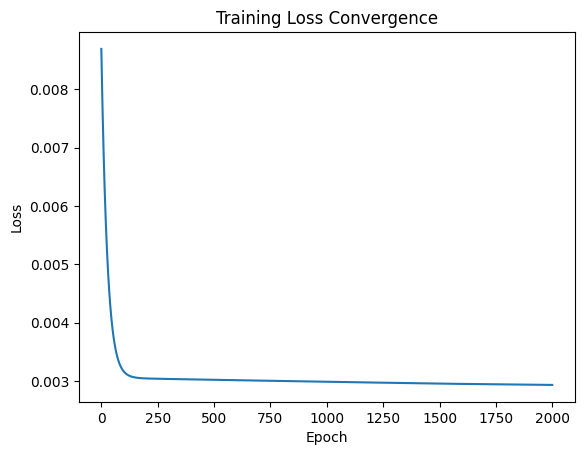

In [19]:

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Convergence")
plt.show()


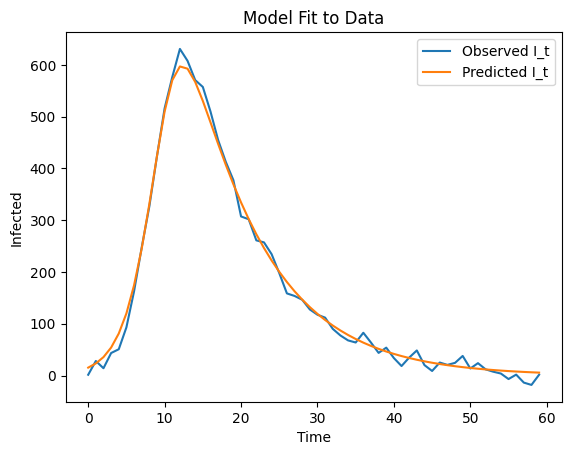

In [20]:
states_trained, betas_trained = simulate_sir_with_dnn(
    trained_params, X_perturbed, S0, I0, R0, gamma
)

I_pred = states_trained[1:, 1]

plt.figure()
plt.plot(y_obs, label="Observed I_t")
plt.plot(I_pred, label="Predicted I_t")
plt.xlabel("Time")
plt.ylabel("Infected")
plt.title("Model Fit to Data")
plt.legend()
plt.show()

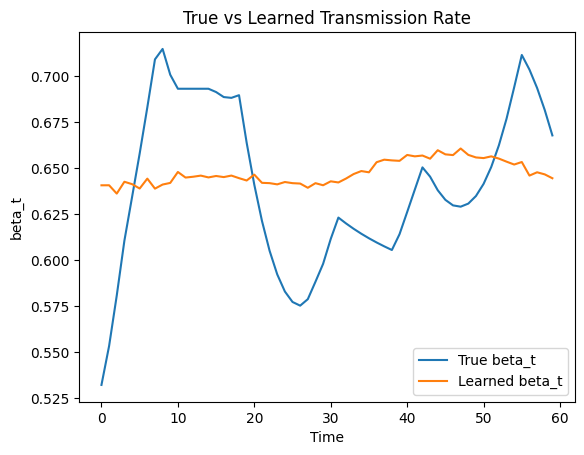

In [21]:
# Compare the true beta_t and the learned beta_t
plt.figure()
plt.plot(betas_true, label="True beta_t")
plt.plot(betas_trained, label="Learned beta_t")
plt.xlabel("Time")
plt.ylabel("beta_t")
plt.title("True vs Learned Transmission Rate")
plt.legend()
plt.show()


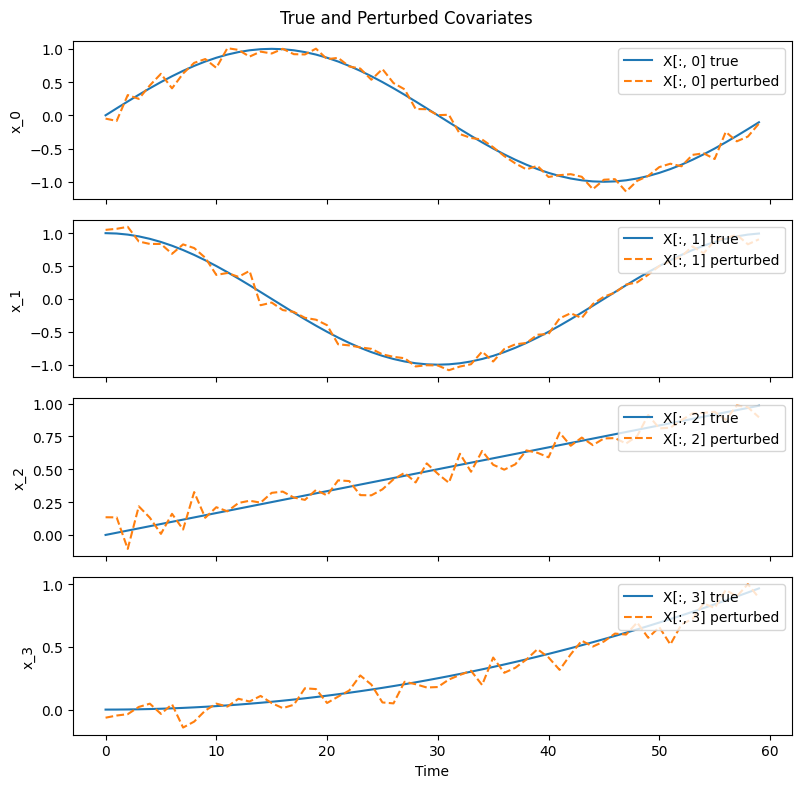

In [22]:
# Compare original and perturbed covariates
fig, axes = plt.subplots(input_dim, 1, figsize=(8, 2 * input_dim), sharex=True)
for i in range(input_dim):
    axes[i].plot(X[:, i], label=f"X[:, {i}] true")
    axes[i].plot(X_perturbed[:, i], "--", label=f"X[:, {i}] perturbed")
    axes[i].legend(loc="upper right")
    axes[i].set_ylabel(f"x_{i}")
axes[-1].set_xlabel("Time")
fig.suptitle("True and Perturbed Covariates")
plt.tight_layout()
plt.show()

## Next step
We separate the transmission dynamics into a baseline
constant component and a flexible covariate-driven residual:
$$
\beta(t) = \beta_0 + \beta'(t),
$$

### Stage 1: Parameter Estimation.
We first fit a standard SIHR model with a baseline transmission rate $\beta_0$
using HMC. This step yields posterior estimates for
$\beta_0$ and other model parameters, and latent epidemic trajectories. The
baseline parameter $\beta_0$ captures the inherent transmission potential of the
population in the absence of external forcing.

### Stage 2: Learning Residual Forcing.
We compute the additional transmission forcing $\beta'(t)$ based on the baseline $\beta_0$. We assume that $\beta'(t)$
captures variation not explained by the baseline SIHR dynamics. We then train a
neural network $g_\theta$ to model $\beta'(t)$ as a function of exogenous
covariates:
$$
\beta'(t) \approx g_\theta(z_t).
$$
This framework naturally decomposes transmission into an interpretable,
mechanistic baseline and a flexible, data-driven component. It also supports
scenario analysis: by perturbing covariates $z_t$, we obtain counterfactual
transmission trajectories.